### RaschPy vector-by-items MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Under the items parameterisation, each rater has a separate severity for every item (rather than a single scalar severity as in the global model).

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Items(no_of_items=8, no_of_persons=40, no_of_raters=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:341: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_52604/1822966266.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set.

In [4]:
sim = rp.MFRM_Sim_Items(no_of_items=8, no_of_persons=200, no_of_raters=8, max_score=5, missing=0, seed=42)
sim.responses.to_csv('mfrm_items_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_items_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     5.0     3.0     4.0     2.0     4.0     4.0     2.0   
        Person_2     4.0     0.0     3.0     0.0     3.0     0.0     0.0   

                  Item_8  
Rater   Person            
Rater_1 Person_1     3.0  
        Person_2     0.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Rater,Person,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the items parameterisation (a separate severity per rater x item combination). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_items()

CPU times: user 2.54 ms, sys: 166 μs, total: 2.71 ms
Wall time: 2.66 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items.head(2)

Item_1   -0.903902
Item_2   -0.358204
dtype: float64

Since this is simulated data, we know the true generating item locations and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery — alongside the Pearson correlation, SD ratio, regression coefficient, and RMSE:

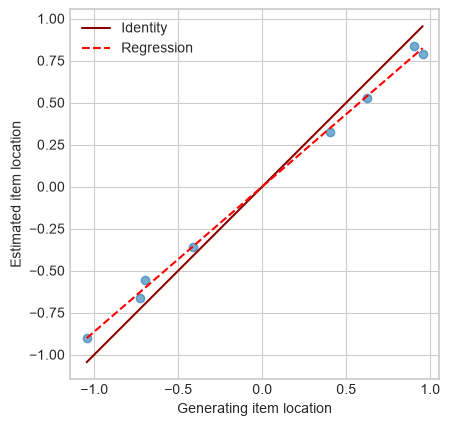

item location Pearson correlation:              0.999
item location SD ratio (estimated / generating): 0.864
item location regression coefficient:            0.863
item location RMSE:                              0.108


In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')

recovery_plot(sim.items, mfrm.items, 'item location', 'my_mfrm_items_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [12]:
%%time
mfrm.item_stats_df_items()
mfrm.item_stats_items.to_csv('mfrm_items_item_stats.csv')

CPU times: user 2.78 s, sys: 28 ms, total: 2.81 s
Wall time: 2.81 s


Check the item statistics table - view the first two items

In [13]:
mfrm.item_stats_items.head(2)

,Estimate,SE,Count,Facility,Infit MS,Outfit MS
Item_1,-0.904,0.041,1600,0.649,0.857,0.864
Item_2,-0.358,0.036,1600,0.572,0.862,0.871


Generate a table of threshold statistics (and check run time), and save to file

In [14]:
%%time
mfrm.threshold_stats_df_items()
mfrm.threshold_stats_items.to_csv('mfrm_items_threshold_stats.csv')

CPU times: user 52.4 ms, sys: 1.47 ms, total: 53.8 ms
Wall time: 53.7 ms


Check the threshold statistics table - view the first two thresholds

In [15]:
mfrm.threshold_stats_items.head(2)

,Estimate,SE,Infit MS,Outfit MS
Threshold 1,-1.666,0.055,0.955,0.933
Threshold 2,-1.577,0.039,0.952,0.968


And the same recovery check for thresholds, against `sim.thresholds`:

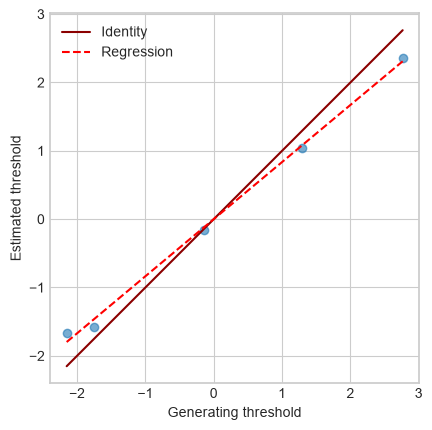

threshold Pearson correlation:              0.999
threshold SD ratio (estimated / generating): 0.837
threshold regression coefficient:            0.835
threshold RMSE:                              0.315


In [16]:
recovery_plot(sim.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_items_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [17]:
%%time
mfrm.rater_stats_df_items()
mfrm.rater_stats_items.to_csv('mfrm_items_rater_stats.csv')

CPU times: user 26.8 ms, sys: 715 μs, total: 27.5 ms
Wall time: 27.4 ms


Check the rater statistics table - view the first two raters

In [18]:
mfrm.rater_stats_items.head(2)

Item_1          Item_2          Item_3          Item_4         \
        Estimate     SE Estimate     SE Estimate     SE Estimate     SE   
Rater_1   -0.548  0.107    0.984  0.124   -0.181  0.100   -0.193  0.110   
Rater_2    0.652  0.121   -0.877  0.118    0.070  0.105    0.445  0.108   

          Item_5          Item_6          Item_7          Item_8         \
        Estimate     SE Estimate     SE Estimate     SE Estimate     SE   
Rater_1    0.195  0.108    0.515  0.112    1.259  0.122   -0.262  0.099   
Rater_2   -0.613  0.124   -0.370  0.092   -0.151  0.110    0.939  0.119   

        Overall statistics                     
                     Count Infit MS Outfit MS  
Rater_1             1600.0    0.908     0.907  
Rater_2             1600.0    0.908     0.896

And the same recovery check for rater x item severities, against `sim.facet_effects`. Since these are per rater x item, we flatten with `.unstack()` first:

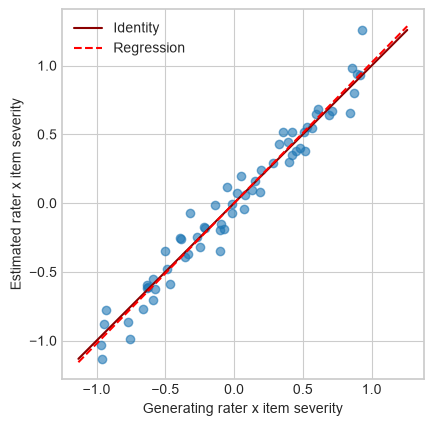

rater x item severity Pearson correlation:              0.981
rater x item severity SD ratio (estimated / generating): 1.042
rater x item severity regression coefficient:            1.022
rater x item severity RMSE:                              0.109


In [19]:
orig_severities = sim.facet_effects.unstack()
est_severities = mfrm.raters_items.unstack()
recovery_plot(orig_severities, est_severities, 'rater x item severity', 'my_mfrm_items_rater_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [20]:
%%time
mfrm.person_stats_df_items()
mfrm.person_stats_items.to_csv('mfrm_items_person_stats.csv')

CPU times: user 9.56 ms, sys: 546 μs, total: 10.1 ms
Wall time: 10.1 ms


Check the person statistics table - view the first two persons

In [21]:
mfrm.person_stats_items.head(2)

,Estimate,CSEM,Score,Max score,p,Infit MS,Outfit MS
Person_1,0.450,0.141,190,320,0.594,0.709,0.708
Person_2,-1.202,0.137,101,320,0.316,0.997,0.947


And the same recovery check for person locations, against `sim.persons`:

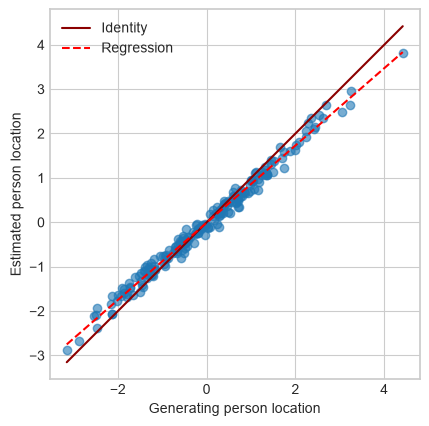

person location Pearson correlation:              0.994
person location SD ratio (estimated / generating): 0.875
person location regression coefficient:            0.87
person location RMSE:                              0.214


In [22]:
recovery_plot(sim.persons, mfrm.persons_items, 'person location', 'my_mfrm_items_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [23]:
%%time
mfrm.test_stats_df_items()
mfrm.test_stats_items.to_csv('mfrm_items_test_stats.csv')

CPU times: user 2.45 ms, sys: 607 μs, total: 3.06 ms
Wall time: 3.04 ms


Check the test statistics table

In [24]:
mfrm.test_stats_items

,Items,Persons
Mean,0.000,-0.009
SD,0.698,1.158
Separation ratio,18.542,8.522
Strata,25.056,11.696
Reliability,0.997,0.986


Run a residual correlation analysis for items (and check run time), and save relevant output to file

In [25]:
%%time
mfrm.item_res_corr_analysis_items()
mfrm.item_residual_correlations_items.to_csv('mfrm_items_item_residual_correlations.csv')
mfrm.item_loadings_items.to_csv('mfrm_items_item_loadings.csv')

CPU times: user 5.04 ms, sys: 1.76 ms, total: 6.8 ms
Wall time: 7.68 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [26]:
mfrm.item_residual_correlations_items

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Item_1,1.000000,-0.005519,-0.015908,-0.009069,-0.030256,-0.014808,-0.074956,-0.021539
Item_2,-0.005519,1.000000,0.029701,-0.019571,-0.055590,-0.017520,0.002151,-0.007128
Item_3,-0.015908,0.029701,1.000000,-0.028962,-0.014307,0.016932,-0.023644,0.011886
Item_4,-0.009069,-0.019571,-0.028962,1.000000,0.041462,-0.051673,-0.008435,-0.012731
Item_5,-0.030256,-0.055590,-0.014307,0.041462,1.000000,-0.027053,0.011253,0.013836
Item_6,-0.014808,-0.017520,0.016932,-0.051673,-0.027053,1.000000,-0.031015,0.007442
Item_7,-0.074956,0.002151,-0.023644,-0.008435,0.011253,-0.031015,1.000000,0.019796
Item_8,-0.021539,-0.007128,0.011886,-0.012731,0.013836,0.007442,0.019796,1.000000


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [27]:
mfrm.item_loadings_items['PC 1']

Item_1   -0.124527
Item_2   -0.141794
Item_3   -0.141587
Item_4    0.182231
Item_5    0.215640
Item_6   -0.152047
Item_7    0.143624
Item_8    0.027233
Name: PC 1, dtype: float64

Run a residual correlation analysis for raters (and check run time), and save relevant output to file

In [28]:
%%time
mfrm.rater_res_corr_analysis_items()
mfrm.rater_residual_correlations_items.to_csv('mfrm_items_rater_residual_correlations.csv')
mfrm.rater_loadings_items.to_csv('mfrm_items_rater_loadings.csv')

CPU times: user 8.7 ms, sys: 549 μs, total: 9.25 ms
Wall time: 9.25 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [29]:
mfrm.rater_residual_correlations_items

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000000,0.002844,0.009592,-0.022803,-0.039515,-0.031503,-0.011176,0.020679
Rater_2,0.002844,1.000000,-0.039024,0.010185,-0.032898,-0.033876,-0.033845,-0.049630
Rater_3,0.009592,-0.039024,1.000000,-0.018858,-0.013783,-0.033277,-0.005732,-0.001960
Rater_4,-0.022803,0.010185,-0.018858,1.000000,-0.059747,-0.004082,0.017514,-0.016717
Rater_5,-0.039515,-0.032898,-0.013783,-0.059747,1.000000,0.017517,-0.075153,0.016826
Rater_6,-0.031503,-0.033876,-0.033277,-0.004082,0.017517,1.000000,-0.016990,-0.051229
Rater_7,-0.011176,-0.033845,-0.005732,0.017514,-0.075153,-0.016990,1.000000,0.014518
Rater_8,0.020679,-0.049630,-0.001960,-0.016717,0.016826,-0.051229,0.014518,1.000000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [30]:
mfrm.rater_loadings_items['PC 1']

Rater_1   -0.067517
Rater_2   -0.076760
Rater_3    0.013291
Rater_4   -0.160289
Rater_5    0.287239
Rater_6    0.154622
Rater_7   -0.185708
Rater_8    0.005921
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

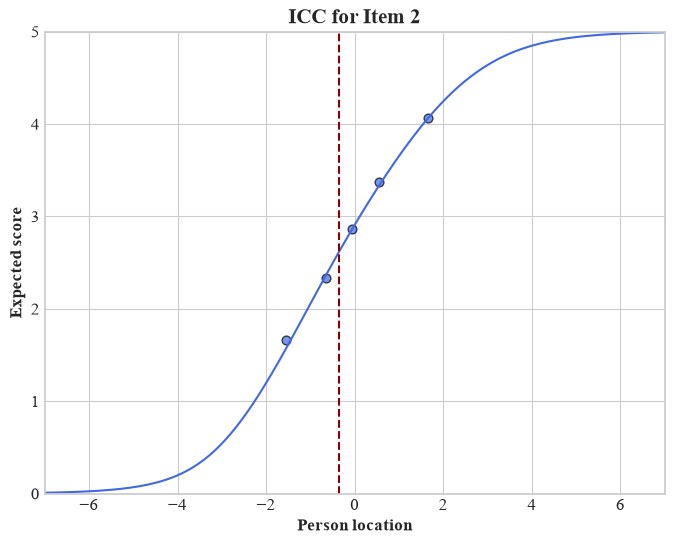

In [31]:
mfrm.icc_items('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_items_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

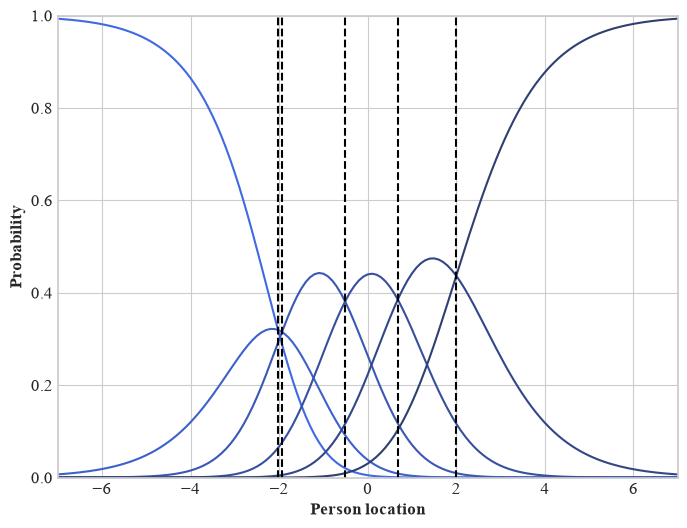

In [32]:
mfrm.crcs_items('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_items_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 3, category 1 highlighted and the thresholds marked

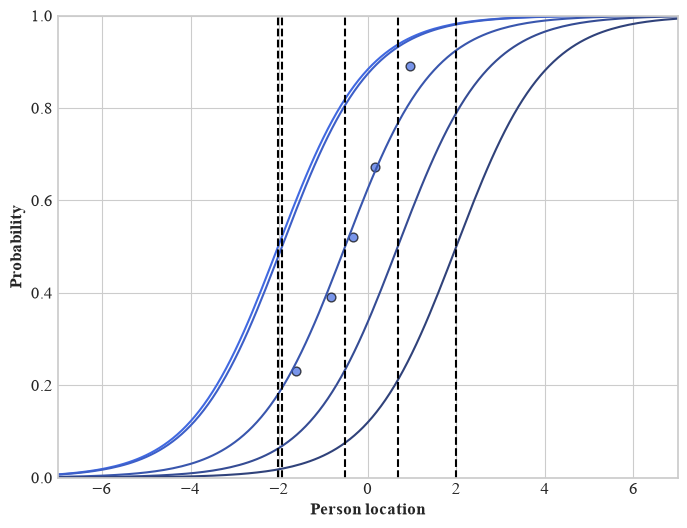

In [33]:
mfrm.threshold_ccs_items('Item_2', thresh_lines=True, obs=[3], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_items_threshold_ccs')

Produce an item information function curve for Item 2

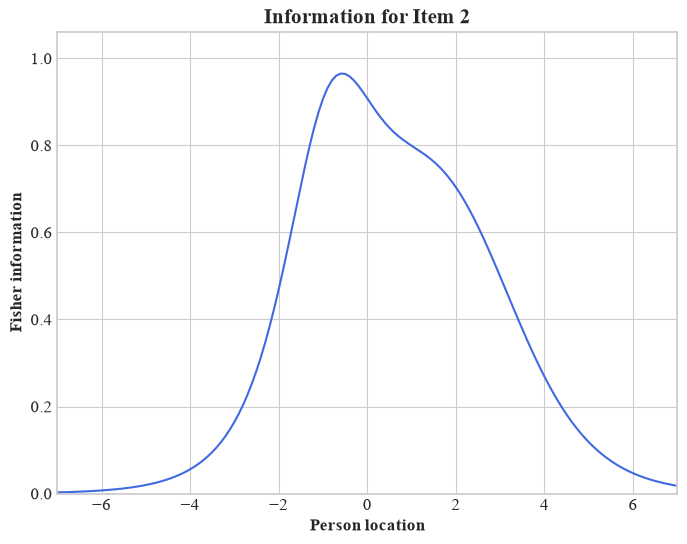

In [34]:
mfrm.iic_items('Item_2', title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_items_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 20 and 30 plotted.

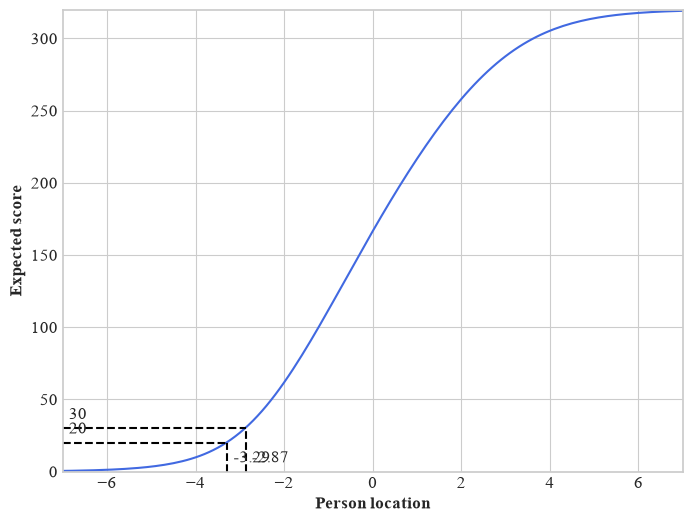

In [35]:
mfrm.tcc_items(score_lines=[20, 30], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_items_tcc')

Produce a test information curve

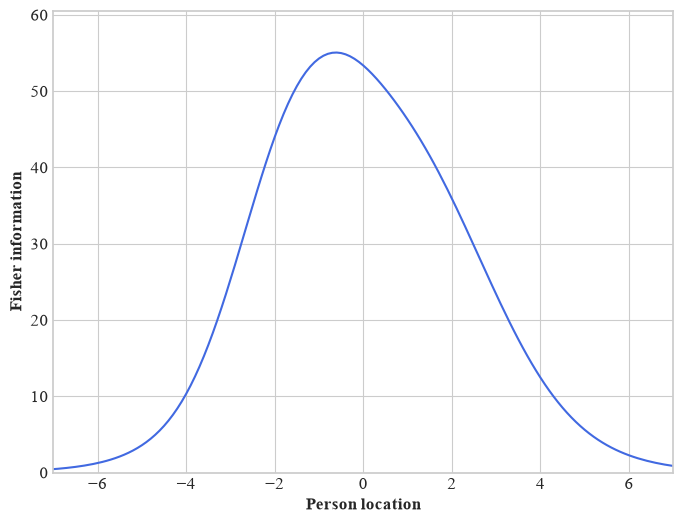

In [36]:
mfrm.test_info_items(xmin=-7, xmax=7, filename='my_mfrm_items_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

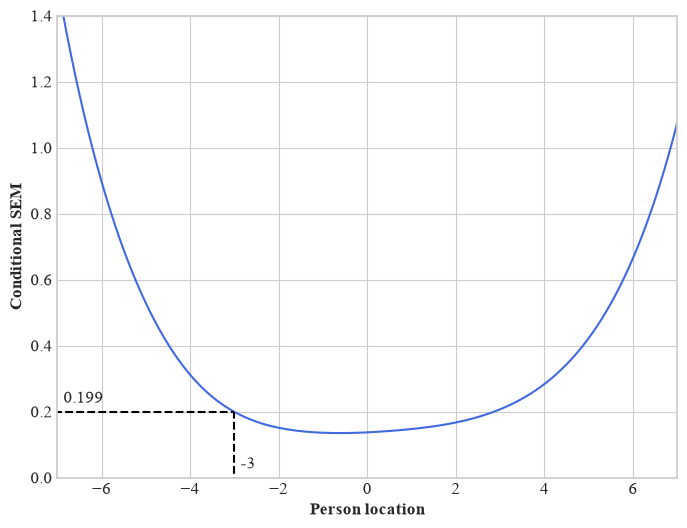

In [37]:
mfrm.test_csem_items(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_items_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

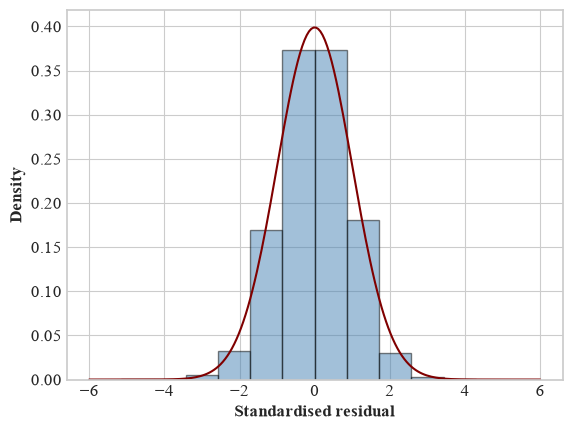

In [38]:
mfrm.std_residuals_plot_items(bin_width=0.6, normal=True, filename='my_mfrm_items_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [39]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_items_anchor(anchors)

CPU times: user 853 μs, sys: 92 μs, total: 945 μs
Wall time: 879 μs


Check the anchored item locations against the unanchored ones.

In [40]:
mfrm.anchor_items_items

Item_1   -0.793439
Item_2   -0.343444
Item_3   -0.630601
Item_4    0.956777
Item_5   -0.627453
Item_6    0.162222
Item_7    0.669594
Item_8    0.606343
dtype: float64

In [41]:
mfrm.items

Item_1   -0.903902
Item_2   -0.358204
Item_3   -0.558144
Item_4    0.838174
Item_5   -0.662797
Item_6    0.327267
Item_7    0.787699
Item_8    0.529908
dtype: float64

Check the anchored rater x item severities against the unanchored ones.

In [42]:
mfrm.raters_items

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Rater_1,-0.548178,0.984305,-0.180907,-0.192700,0.195052,0.515492,1.258647,-0.261894
Rater_2,0.651888,-0.877337,0.069820,0.444556,-0.612669,-0.369871,-0.151457,0.939019
Rater_3,0.237595,0.802053,0.348291,0.160820,0.375751,-0.866998,-0.772997,0.402711
Rater_4,0.556240,-0.394287,-0.071338,0.517431,0.638938,0.516892,-0.350922,-0.318401
Rater_5,0.113462,0.290842,0.544502,0.091653,-0.074141,-0.014737,0.301685,0.377397
Rater_6,-0.614666,-0.986820,0.059991,-0.251341,0.649317,-0.006718,-0.622112,0.669125
Rater_7,-0.479888,-0.245263,-0.597372,-0.585751,-1.132212,-0.706460,-0.349823,-0.776953
Rater_8,0.083547,0.426507,-0.172987,-0.184666,-0.040036,0.932401,0.686979,-1.031004


In [43]:
mfrm.anchor_raters_items

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Rater_1,-0.772564,0.855622,-0.222374,-0.425227,0.045784,0.566613,1.262829,-0.452253
Rater_2,0.427502,-1.006021,0.028354,0.212029,-0.761937,-0.318750,-0.147274,0.748660
Rater_3,0.013209,0.673369,0.306824,-0.071707,0.226483,-0.815877,-0.768815,0.212352
Rater_4,0.331854,-0.522970,-0.112804,0.284904,0.489670,0.568013,-0.346740,-0.508760
Rater_5,-0.110924,0.162159,0.503035,-0.140873,-0.223409,0.036384,0.305867,0.187038
Rater_6,-0.839053,-1.115504,0.018525,-0.483867,0.500049,0.044404,-0.617930,0.478766
Rater_7,-0.704275,-0.373946,-0.638838,-0.818278,-1.281480,-0.655339,-0.345641,-0.967312
Rater_8,-0.140839,0.297823,-0.214453,-0.417192,-0.189304,0.983522,0.691161,-1.221363
